# GRU attention decoder with an attended noise state: neural dynamics to DINOv3 features

## Main idea

This notebook applies the negative control of `noise_layer_baseline_model_dev.ipynb` to the reversed GRU decoder of `GRU_attn_neural_to_features_model_dev.ipynb`. In the noise-layer baseline, attention ranges over ANN layers, so a Gaussian-noise vector is appended as one extra layer. Here attention ranges over neural time, so the analogue is one extra **noise pseudo-state** appended after the last GRU state. Every target-layer query then attends over `T + 1` items: `T` stimulus-driven states and one stimulus-independent item.

The central questions are:

> Does each DINOv3 layer query learn to reject the noise state, and does competing with it change how well the decoder recovers the targets?

```text
Neural response X [B, T, C]
    |
    +-- optional Linear(C -> C_b) + LayerNorm + dropout
    |
    v
Variational-dropout GRU -> all states H [B, T, H]
    +
Uniform-sphere noise state, norm-matched to mean ||h_t||  [B, 1, H]
    | concatenate along the time/item axis
    v
Attended items [B, T + 1, H]
    |
    +-- q_shallow -> softmax over T + 1 -> z_shallow -> head -> PCA shallow
    +-- q_mid     -> softmax over T + 1 -> z_mid     -> head -> PCA mid
    +-- q_deep    -> softmax over T + 1 -> z_deep    -> head -> PCA deep
```

For presentation $b$, the noise item is $\epsilon_b = \bar n_b\, u_b / \lVert u_b \rVert$ with $u_b \sim \mathcal N(0, I_H)$ and $\bar n_b = \frac1T\sum_t \lVert h_{bt} \rVert$. Writing $h_{b,T+1}=\epsilon_b$, layer $l$ uses

$$s_{blt}=q_l^T h_{bt}/\sqrt{H},\quad \alpha_{bl}=\operatorname{softmax}_{t\in\{1..T+1\}}(s_{bl}),\quad z_{bl}=\sum_{t=1}^{T+1}\alpha_{blt}h_{bt}.$$

$\alpha_{bl,T+1}$ is the attention mass spent on noise. Uniform attention would give it $1/(T+1)$. Mass on the noise item both dilutes the pooled state and injects variance into it, so a query that keeps it low has learned to reject uninformative items. This is the same regularization-by-competition argument as the noise-layer baseline.

## Fair comparison

The plain GRU and the noise-state GRU are built from the same seed and have identical parameters, since the noise model adds none. Both use the same image-grouped split, minibatch order, optimizer, and early stopping. The flattened-neural ridge is the shared non-recurrent reference.

As in the noise-layer baseline, `noise_in_eval=True` keeps sampling noise at evaluation time. Early stopping therefore sees one noise draw per validation pass, while the final scores and attention maps average `noise_evaluation_repeats` independent draws. Set `noise_in_eval=False` to evaluate with a zero noise item instead. With one image split, differences of a few thousandths are within split and seed variability, so replicate before believing a small gain.

In [1]:
import os
import sys
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from sklearn.linear_model import RidgeCV
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder

# Locate the repository whether Jupyter starts at root or in scripts/.
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in [cwd, *cwd.parents] if (path / 'config.yaml').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate config.yaml.')
# end if project root was not found

ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')
with open(PROJECT_ROOT / 'config.yaml', 'r') as f:
    config = yaml.safe_load(f)
paths = config[ENV]['paths']

project_src_path = str((PROJECT_ROOT / 'python_scripts' / 'src').resolve())
useful_stuff_path = str(Path(paths['useful_stuff_path']).resolve())
for source_path in (useful_stuff_path, project_src_path):
    while source_path in sys.path:
        sys.path.remove(source_path)
    # end while source path is already registered
    sys.path.insert(0, source_path)
# end for source path

from IT_recap.hf_feature_extraction import is_valid_image_file, load_hf_layer_features
from IT_recap.neural_feature_decoding import (
    NeuralLayerFeatureDataset,
    average_rows_by_image,
    collect_feature_decoder_outputs,
    fit_feature_decoder,
    fit_layer_pcas,
    fit_neural_channel_standardizer,
    plot_layer_feature_reconstruction,
    score_layer_predictions,
)
from IT_recap.neural_prediction_training import mean_stimulus_correlation
from IT_recap.dynamic_drsa import (
    drsa_from_prepared,
    plot_drsa_matrix,
    prepared_rdm_time_series,
    time_axis_ms,
)
from model_classes.temporal_models import (
    NeuralToLayerFeatureGRUModel,
    NoiseStateGRUFeatureModel,
)
from project_specific_utils.dataloader import (
    load_img_natraster,
    load_img_raster,
    map_image_order_from_ann_to_monkey,
    map_trial_image_order_to_ann,
)

In [5]:
@dataclass
class Cfg:
    # Neural recording and image alignment.
    neural_data_source: str = 'natraster'  # 'raster' (~22K trials) or 'natraster'
    monkey_name: str = 'three0'
    date: str = '250313'
    brain_area: str = 'AIT'
    folder_name: str = 'talia_20each_tizi'
    raster_file: str = 'rasters_three0_250313to21.mat'
    raster_key: str = 'rasters'
    raster_image_names_file: str = 'allimages_three0_250313to21.mat'
    raster_image_names_key: str = 'allimages'
    original_fs: int = 1000
    new_fs: int = 100
    time_start_ms: float = 0.0
    time_end_ms: float = 300.0
    raster_chunk_size: int = 512

    # Three DINOv3 targets, independently reduced with train-only PCA.
    model_name: str = 'dino_v3_l'
    img_size: int = 224
    pooling: str = 'mean'
    layer_names: list[str] = field(default_factory=lambda: [
        'layer.3.mlp.down_proj',
        'layer.13.mlp.down_proj',
        'layer.20.mlp.down_proj',
    ])
    layer_labels: list[str] = field(default_factory=lambda: [
        'shallow', 'mid', 'deep'
    ])
    target_pca_components: int = 64
    whiten_pca: bool = True

    # Image-grouped split and optimization.
    validation_fraction: float = 0.2
    random_seed: int = 0
    batch_size: int = 256
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4

    # Architecture shared by both decoders, as in the plain GRU notebook.
    hidden_dim: int = 16
    n_gru_layers: int = 1
    bottleneck_dim: int | None = 16  # Set to None to bypass it.
    head_type: str = 'linear'  # 'linear' or 'mlp'
    head_hidden_dim: int = 16  # Used only by the MLP head.
    variational_dropout: float = 0.15
    hidden_dropout: float = 0.25
    head_dropout: float = 0.25

    # Noise pseudo-state appended to the attended GRU sequence.
    match_noise_norm: bool = True
    noise_in_eval: bool = False
    noise_evaluation_repeats: int = 20
    # Layer-wise RSA compares decoded geometries across validation images.
    drsa_rdm_metric: str = 'euclidean'
    drsa_rsa_metric: str = 'spearman'
    reconstruction_plot_interval: int = 100
    reconstruction_sample_index: int = 10

    # The plain GRU notebook's 200 epochs stop while validation MSE still falls;
    # patience ends training once it has actually plateaued.
    epochs: int = 200
    patience: int = 20
    ridge_alphas: np.ndarray = field(
        default_factory=lambda: np.logspace(-4, 4, 17)
    )
# EOC

cfg = Cfg()
cfg

Cfg(neural_data_source='natraster', monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', raster_file='rasters_three0_250313to21.mat', raster_key='rasters', raster_image_names_file='allimages_three0_250313to21.mat', raster_image_names_key='allimages', original_fs=1000, new_fs=100, time_start_ms=0.0, time_end_ms=300.0, raster_chunk_size=512, model_name='dino_v3_l', img_size=224, pooling='mean', layer_names=['layer.3.mlp.down_proj', 'layer.13.mlp.down_proj', 'layer.20.mlp.down_proj'], layer_labels=['shallow', 'mid', 'deep'], target_pca_components=64, whiten_pca=True, validation_fraction=0.2, random_seed=0, batch_size=256, learning_rate=0.001, weight_decay=0.0001, hidden_dim=16, n_gru_layers=1, bottleneck_dim=16, head_type='linear', head_hidden_dim=16, variational_dropout=0.15, hidden_dropout=0.25, head_dropout=0.25, match_noise_norm=True, noise_in_eval=False, noise_evaluation_repeats=20, drsa_rdm_metric='euclidean', drsa_rsa_metric='spearman', reconstruc

## Load and align neural inputs with static DINOv3 targets

Identical to the plain GRU notebook. The cached feature array remains in `ImageFolder` order, and neural samples are mapped to that order before the model input is transposed to `(presentation, time, channels)`.

In [6]:
dataset_path = Path(paths['livingstone_lab']) / 'Stimuli' / cfg.folder_name
image_dataset = ImageFolder(
    root=dataset_path,
    is_valid_file=is_valid_image_file,
    allow_empty=True,
)

if cfg.neural_data_source == 'raster':
    raster, neural_image_names = load_img_raster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        raster_file=cfg.raster_file,
        image_names_file=cfg.raster_image_names_file,
        raster_key=cfg.raster_key,
        image_names_key=cfg.raster_image_names_key,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
        chunk_size=cfg.raster_chunk_size,
    )
    neural_image_indices = map_trial_image_order_to_ann(
        neural_image_names, image_dataset
    )
elif cfg.neural_data_source == 'natraster':
    raster = load_img_natraster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        date=cfg.date,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
    )
    neural_image_indices = np.asarray(
        map_image_order_from_ann_to_monkey(
            paths, cfg.monkey_name, cfg.date, image_dataset
        ),
        dtype=int,
    )
else:
    raise ValueError("neural_data_source must be 'raster' or 'natraster'.")
# end if repeated or averaged neural data are requested

raster_array = raster.get_array()
layer_features = load_hf_layer_features(
    output_dir=Path(paths['data_path']) / 'models',
    dataset_name=cfg.folder_name,
    model_name=cfg.model_name,
    img_size=cfg.img_size,
    layer_names=cfg.layer_names,
    pooling=cfg.pooling,
)
if layer_features.shape[:2] != (len(image_dataset), len(cfg.layer_names)):
    raise ValueError('Cached targets do not align with images and layer names.')
# end if cached target alignment is invalid
print(f'neural [channels, time, samples]: {raster_array.shape}')
print(f'DINOv3 [images, layers, embedding]: {layer_features.shape}')
print(f'aligned unique images: {len(np.unique(neural_image_indices))}')

neural [channels, time, samples]: (25, 30, 776)
DINOv3 [images, layers, embedding]: (776, 3, 1024)
aligned unique images: 776


## Leakage-safe image split, PCA targets, and neural scaling

Unique images are split before trials, so repetitions never cross partitions. Each layer gets its own whitened 64-component PCA fitted on training images, and neural channels are standardized from training trials only.

In [7]:
if not 0.0 < cfg.validation_fraction < 1.0:
    raise ValueError('validation_fraction must lie between zero and one.')
# end if validation fraction is invalid
split_rng = np.random.default_rng(cfg.random_seed)
unique_image_indices = np.unique(neural_image_indices)
shuffled_images = split_rng.permutation(unique_image_indices)
n_validation_images = max(1, round(len(shuffled_images) * cfg.validation_fraction))
validation_image_indices = shuffled_images[:n_validation_images]
training_image_indices = shuffled_images[n_validation_images:]
is_validation_trial = np.isin(neural_image_indices, validation_image_indices)
training_trial_indices = np.flatnonzero(~is_validation_trial)
validation_trial_indices = np.flatnonzero(is_validation_trial)
if set(training_image_indices) & set(validation_image_indices):
    raise RuntimeError('An image appears in both training and validation.')
# end if repeated stimuli leaked across the split

image_targets, layer_pcas, target_slices = fit_layer_pcas(
    layer_features,
    training_image_indices,
    n_components=cfg.target_pca_components,
    random_seed=cfg.random_seed,
    whiten=cfg.whiten_pca,
)
target_dims = [target_slice.stop - target_slice.start for target_slice in target_slices]
channel_mean, channel_std = fit_neural_channel_standardizer(
    raster_array, training_trial_indices
)
full_dataset = NeuralLayerFeatureDataset(
    raster_array,
    image_targets,
    neural_image_indices,
    channel_mean,
    channel_std,
)
training_dataset = Subset(full_dataset, training_trial_indices.tolist())
validation_dataset = Subset(full_dataset, validation_trial_indices.tolist())
pin_memory = torch.cuda.is_available()

def make_loaders(seed):
    # Re-seeding gives both decoders exactly the same minibatch order.
    generator = torch.Generator().manual_seed(seed)
    training_loader = DataLoader(
        training_dataset, batch_size=cfg.batch_size, shuffle=True,
        pin_memory=pin_memory, generator=generator,
    )
    validation_loader = DataLoader(
        validation_dataset, batch_size=cfg.batch_size, shuffle=False,
        pin_memory=pin_memory,
    )
    return training_loader, validation_loader
# EOF

for label, pca in zip(cfg.layer_labels, layer_pcas):
    explained = pca.explained_variance_ratio_.sum()
    print(f'{label:8s}: {pca.n_components_} PCs, {explained:.3f} variance retained')
# end for fitted layer PCA
print(
    f'split: {len(training_image_indices)} images / {len(training_trial_indices)} trials train; '
    f'{len(validation_image_indices)} images / {len(validation_trial_indices)} trials validation'
)

shallow : 64 PCs, 0.958 variance retained
mid     : 64 PCs, 0.835 variance retained
deep    : 64 PCs, 0.738 variance retained
split: 621 images / 621 trials train; 155 images / 155 trials validation


## Build both decoders and inspect the noise state

Both decoders are constructed after re-seeding, so they start from identical weights. The shape trace confirms that the noise model's attention has one more column than there are neural time bins, and that the appended item has the mean norm of that presentation's GRU states.

In [8]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
# end if an accelerator is available

model_kwargs = dict(
    n_neural_channels=raster_array.shape[0],
    target_dims=target_dims,
    target_names=cfg.layer_labels,
    hidden_dim=cfg.hidden_dim,
    n_gru_layers=cfg.n_gru_layers,
    bottleneck_dim=cfg.bottleneck_dim,
    variational_dropout=cfg.variational_dropout,
    hidden_dropout=cfg.hidden_dropout,
    head_dropout=cfg.head_dropout,
    head_type=cfg.head_type,
    head_hidden_dim=cfg.head_hidden_dim,
)
torch.manual_seed(cfg.random_seed)
baseline_model = NeuralToLayerFeatureGRUModel(**model_kwargs).to(device)
torch.manual_seed(cfg.random_seed)
noise_model = NoiseStateGRUFeatureModel(
    match_noise_norm=cfg.match_noise_norm,
    noise_in_eval=cfg.noise_in_eval,
    **model_kwargs,
).to(device)

# The noise model adds no parameters, so equal seeds mean equal initial weights.
baseline_state = baseline_model.state_dict()
for parameter_name, parameter in noise_model.state_dict().items():
    if not torch.equal(parameter, baseline_state[parameter_name]):
        raise RuntimeError(f'Initial weights differ at {parameter_name}.')
    # end if the two decoders start from different weights
# end for model parameter
n_parameters = sum(parameter.numel() for parameter in noise_model.parameters())
print(noise_model)
print(f'\ntrainable parameters in each decoder: {n_parameters:,d}')

# Trace one validation batch through the noise model in evaluation mode.
_, validation_loader = make_loaders(cfg.random_seed)
example_neural, example_targets = next(iter(validation_loader))
noise_model.eval()
with torch.no_grad():
    example_predictions, example_attention, example_hidden = noise_model(
        example_neural.to(device), return_hidden_states=True
    )
    example_items = noise_model._build_attended_states(example_hidden)
# end with no gradient tracking
noise_norm = example_items[:, -1].norm(dim=-1)
state_norm = example_hidden.norm(dim=-1).mean(dim=1)
print('\nShape trace:')
print(f'  neural input      {tuple(example_neural.shape)}  [B, T, C]')
print(f'  all GRU states   {tuple(example_hidden.shape)}  [B, T, H]')
print(f'  attended items   {tuple(example_items.shape)}  [B, T + 1, H]')
print(f'  layer attention  {tuple(example_attention.shape)}  [B, layers, T + 1]')
print(f'  PCA prediction   {tuple(example_predictions.shape)}  [B, sum(D_l)]')
print(
    f'  noise / mean state norm: {(noise_norm / state_norm).mean().item():.3f} '
    f'(1.0 when match_noise_norm=True)'
)

NoiseStateGRUFeatureModel(
  (input_bottleneck): Sequential(
    (0): Linear(in_features=25, out_features=16, bias=True)
    (1): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): Dropout(p=0.25, inplace=False)
  )
  (encoder): VariationalGRUEncoder(
    (cells): ModuleList(
      (0): GRUCell(16, 16)
    )
  )
  (hidden_sequence_dropout): Dropout(p=0.25, inplace=False)
  (regression_heads): ModuleList(
    (0-2): 3 x Sequential(
      (0): Dropout(p=0.25, inplace=False)
      (1): Linear(in_features=16, out_features=64, bias=True)
    )
  )
)

trainable parameters in each decoder: 5,392

Shape trace:
  neural input      (155, 30, 25)  [B, T, C]
  all GRU states   (155, 30, 16)  [B, T, H]
  attended items   (155, 31, 16)  [B, T + 1, H]
  layer attention  (155, 3, 31)  [B, layers, T + 1]
  PCA prediction   (155, 192)  [B, sum(D_l)]
  noise / mean state norm: 0.000 (1.0 when match_noise_norm=True)


# Training and online validation
## training (repeat for the whole training set -> 1 epoch)
1. Pass minibatch
2. compute the layer-balanced loss
3. backpropagate
4. do the optimizer step
5. zero the gradient
6. accumulate the sample-weighted training loss

## testing (repeat for the whole validation set at every epoch)
1. switch the network to evaluation mode
2. compute the loss
3. accumulate the sample-weighted validation loss
4. average repeated presentations by image and compute mean stim_r

Both decoders train from the same seed and minibatch order, with early stopping restoring the best-validation parameters. Mean stim_r is the across-image Pearson correlation of every whitened PCA coordinate, averaged over coordinates. It plays the role of the time-neuron cells in the noise-layer notebook. Reconstructions of one validation presentation are plotted at epoch 0, every `reconstruction_plot_interval` epochs, and for the restored best model. Ridge and a predict-training-mean baseline are fitted on the same split.

GRU + noise state | epoch 000/200 | train stim_r 0.0043 | validation stim_r 0.0071


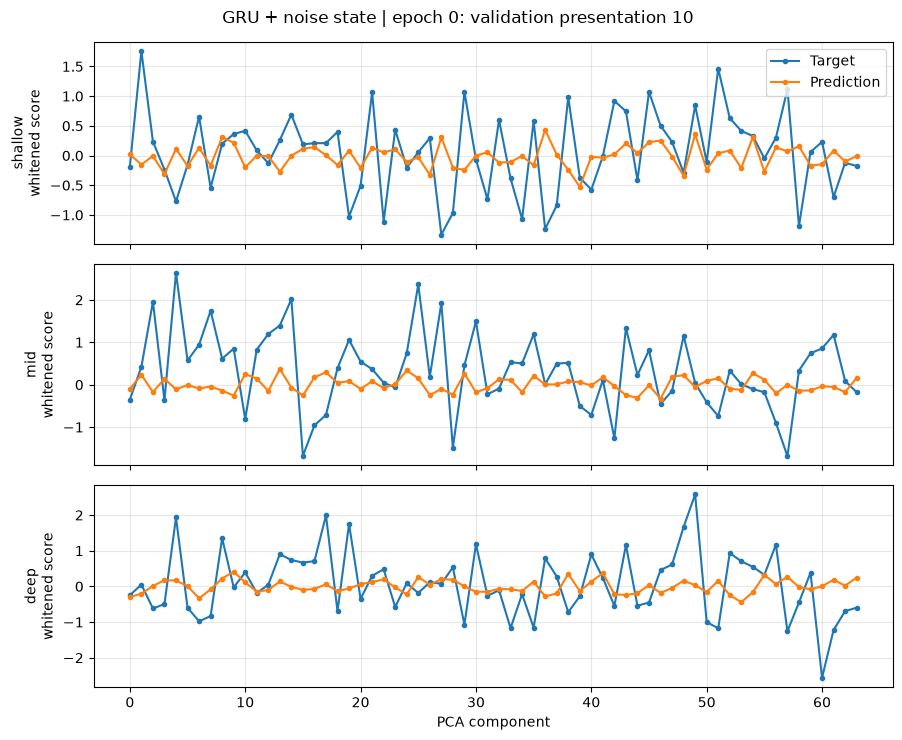

GRU + noise state | epoch 001/200 | train stim_r 0.0067 | validation stim_r 0.0093
GRU + noise state | epoch 002/200 | train stim_r 0.0091 | validation stim_r 0.0114
GRU + noise state | epoch 003/200 | train stim_r 0.0113 | validation stim_r 0.0135
GRU + noise state | epoch 004/200 | train stim_r 0.0137 | validation stim_r 0.0157
GRU + noise state | epoch 005/200 | train stim_r 0.0161 | validation stim_r 0.0177
GRU + noise state | epoch 006/200 | train stim_r 0.0187 | validation stim_r 0.0197
GRU + noise state | epoch 007/200 | train stim_r 0.0212 | validation stim_r 0.0216
GRU + noise state | epoch 008/200 | train stim_r 0.0237 | validation stim_r 0.0233
GRU + noise state | epoch 009/200 | train stim_r 0.0262 | validation stim_r 0.0249
GRU + noise state | epoch 010/200 | train stim_r 0.0287 | validation stim_r 0.0264
GRU + noise state | epoch 011/200 | train stim_r 0.0311 | validation stim_r 0.0277
GRU + noise state | epoch 012/200 | train stim_r 0.0336 | validation stim_r 0.0292
GRU 

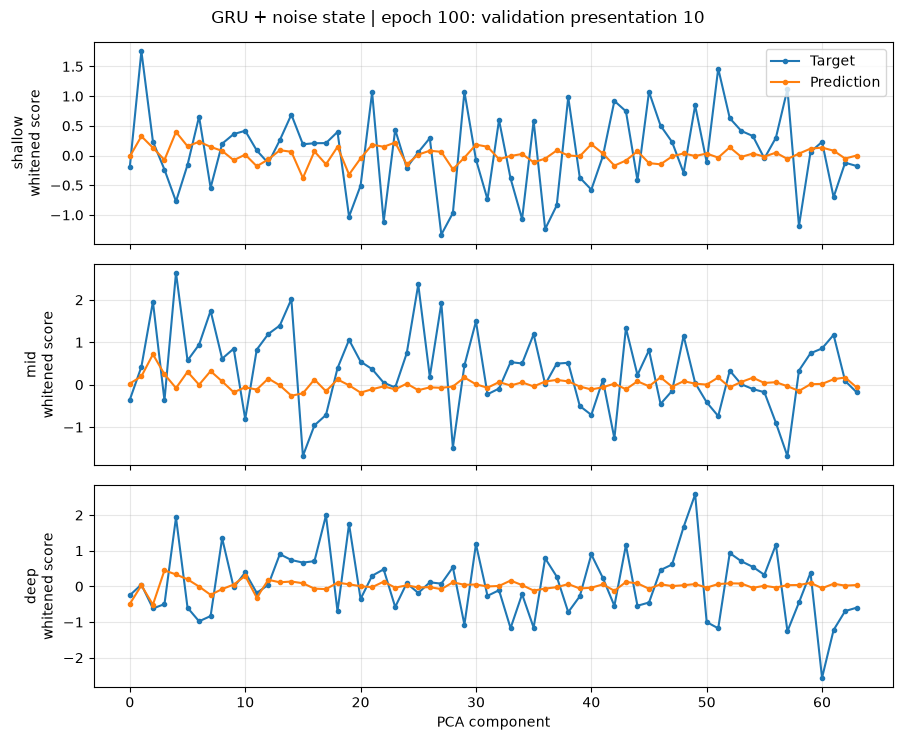

GRU + noise state | epoch 101/200 | train stim_r 0.1387 | validation stim_r 0.0949
GRU + noise state | epoch 102/200 | train stim_r 0.1394 | validation stim_r 0.0953
GRU + noise state | epoch 103/200 | train stim_r 0.1401 | validation stim_r 0.0958
GRU + noise state | epoch 104/200 | train stim_r 0.1407 | validation stim_r 0.0963
GRU + noise state | epoch 105/200 | train stim_r 0.1413 | validation stim_r 0.0966
GRU + noise state | epoch 106/200 | train stim_r 0.1418 | validation stim_r 0.0970
GRU + noise state | epoch 107/200 | train stim_r 0.1423 | validation stim_r 0.0973
GRU + noise state | epoch 108/200 | train stim_r 0.1428 | validation stim_r 0.0976
GRU + noise state | epoch 109/200 | train stim_r 0.1433 | validation stim_r 0.0980
GRU + noise state | epoch 110/200 | train stim_r 0.1438 | validation stim_r 0.0984
GRU + noise state | epoch 111/200 | train stim_r 0.1442 | validation stim_r 0.0988
GRU + noise state | epoch 112/200 | train stim_r 0.1447 | validation stim_r 0.0992
GRU 

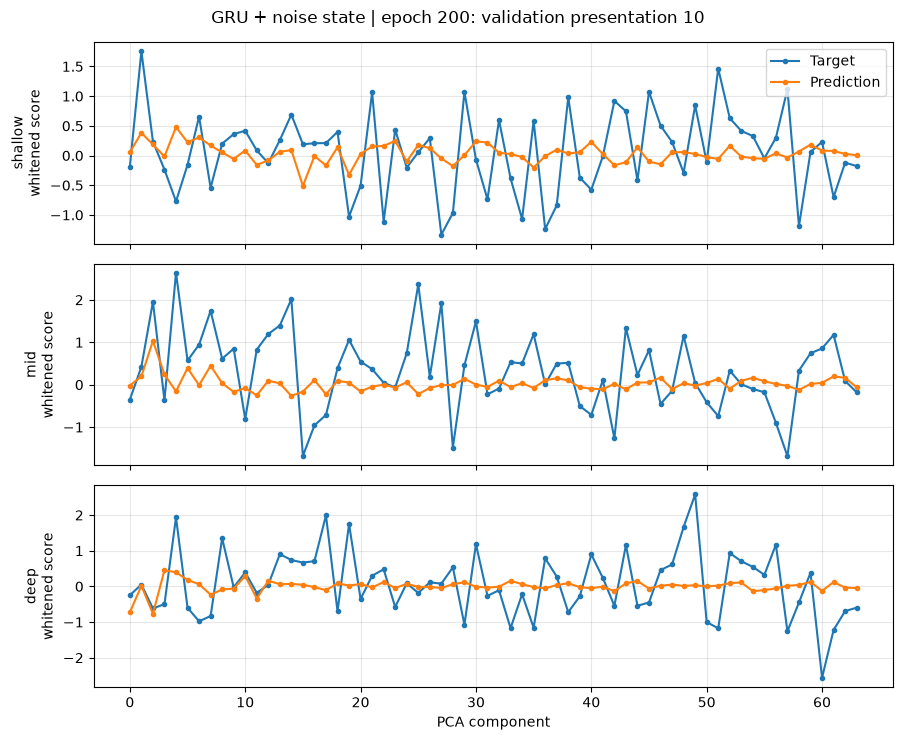

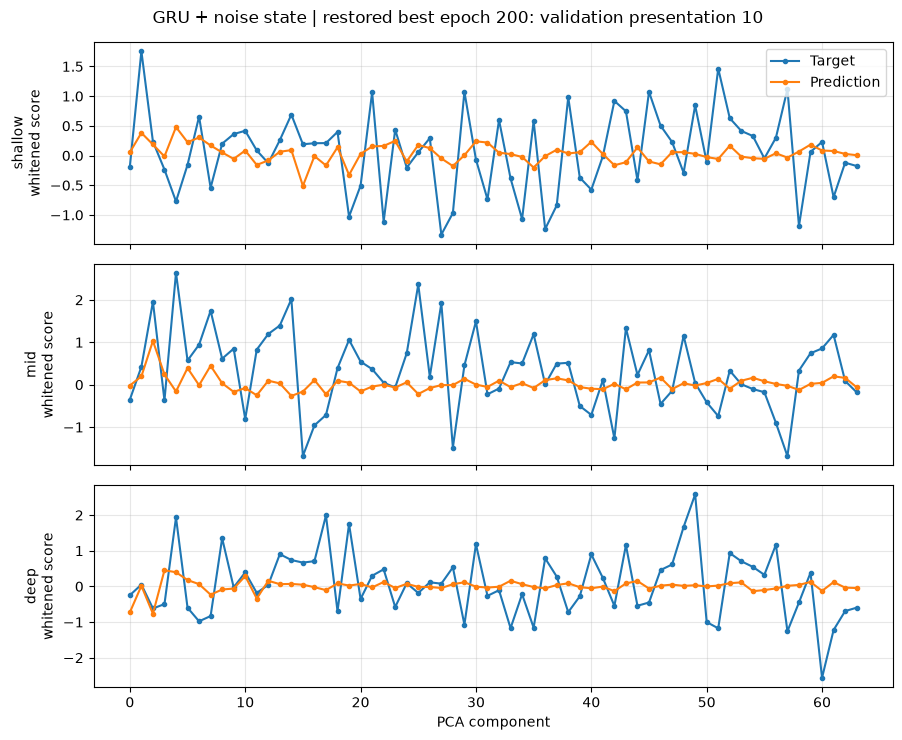

flattened-neural ridge | validation layer-balanced MSE 0.746322 | mean stim_r 0.1175 (alpha=1e+04)
predict training mean | validation layer-balanced MSE 0.763541 | mean stim_r undefined (prediction is constant across images)
GRU                | best epoch 197 | validation MSE 0.743676 | mean stim_r 0.1163 | MSE reduction vs mean 2.6%
GRU + noise state  | best epoch 200 | validation MSE 0.743829 | mean stim_r 0.1145 | MSE reduction vs mean 2.6%
ridge MSE reduction vs mean 2.3%


In [9]:
validation_trial_image_indices = neural_image_indices[validation_trial_indices]
training_trial_image_indices = neural_image_indices[training_trial_indices]
# Unshuffled training order, used only to score training stim_r every epoch.
training_evaluation_loader = DataLoader(
    training_dataset, batch_size=cfg.batch_size, shuffle=False, pin_memory=pin_memory,
)
sample_idx = min(cfg.reconstruction_sample_index, len(validation_dataset) - 1)
sample_neural, sample_target = validation_dataset[sample_idx]

def image_level_stim_r(model, data_loader, image_ids):
    # Average presentations by image, then correlate each PCA coordinate across
    # images; [images, 1, D] matches the [images, time, channels] helper.
    predictions, targets, _, _ = collect_feature_decoder_outputs(
        model, data_loader, device=device
    )
    image_predictions, _ = average_rows_by_image(predictions, image_ids)
    image_targets, _ = average_rows_by_image(targets, image_ids)
    return mean_stimulus_correlation(
        image_predictions[:, None, :], image_targets[:, None, :]
    )
# EOF

def plot_sample_reconstruction(model, title):
    model.eval()
    with torch.no_grad():
        sample_prediction, _ = model(sample_neural[None].to(device))
    # end with no gradient tracking
    plot_layer_feature_reconstruction(
        sample_prediction[0].cpu().numpy(),
        sample_target.numpy(),
        target_slices,
        cfg.layer_labels,
        title=title,
    )
# EOF

def make_epoch_callback(decoder_label, verbose):
    def epoch_callback(model, epoch):
        training_correlation = image_level_stim_r(
            model, training_evaluation_loader, training_trial_image_indices
        )
        validation_correlation = image_level_stim_r(
            model, validation_loader, validation_trial_image_indices
        )
        if verbose:
            print(
                f'{decoder_label} | epoch {epoch:03d}/{cfg.epochs:03d} | '
                f'train stim_r {training_correlation:.4f} | '
                f'validation stim_r {validation_correlation:.4f}'
            )
            if epoch % cfg.reconstruction_plot_interval == 0:
                plot_sample_reconstruction(
                    model,
                    f'{decoder_label} | epoch {epoch}: validation presentation {sample_idx}',
                )
            # end if reconstruction should be plotted
        # end if progress is reported for this decoder
        return {
            'training_correlations': training_correlation,
            'validation_correlations': validation_correlation,
        }
    # EOF
    return epoch_callback
# EOF

decoders = {
    'GRU': baseline_model,
    'GRU + noise state': noise_model,
}
histories = {}
for decoder_label, decoder in decoders.items():
    training_loader, validation_loader = make_loaders(cfg.random_seed)
    torch.manual_seed(cfg.random_seed)
    histories[decoder_label] = fit_feature_decoder(
        decoder,
        training_loader,
        validation_loader,
        target_slices,
        learning_rate=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        max_epochs=cfg.epochs,
        patience=cfg.patience,
        device=device,
        epoch_callback=make_epoch_callback(
            decoder_label, verbose=decoder is noise_model
        ),
    )
# end for decoder
plot_sample_reconstruction(
    noise_model,
    f"GRU + noise state | restored best epoch "
    f"{histories['GRU + noise state']['best_epoch']}: validation presentation {sample_idx}",
)

def layer_balanced_mse(predictions, targets):
    return float(np.mean([
        np.mean((predictions[:, s] - targets[:, s]) ** 2) for s in target_slices
    ]))
# EOF

# Fit ridge on the flattened standardized neural time series.
all_neural_inputs = full_dataset.neural_sequences.numpy().reshape(len(full_dataset), -1)
all_targets = full_dataset.image_targets[full_dataset.image_indices].numpy()
ridge = RidgeCV(alphas=cfg.ridge_alphas)
ridge.fit(all_neural_inputs[training_trial_indices], all_targets[training_trial_indices])
ridge_validation_predictions = ridge.predict(all_neural_inputs[validation_trial_indices])
ridge_validation_targets = all_targets[validation_trial_indices]
ridge_validation_mse = layer_balanced_mse(ridge_validation_predictions, ridge_validation_targets)

# The predict-mean baseline is estimated only from training presentations.
training_mean_prediction = all_targets[training_trial_indices].mean(axis=0, keepdims=True)
mean_validation_predictions = np.broadcast_to(
    training_mean_prediction, ridge_validation_targets.shape
)
mean_validation_mse = layer_balanced_mse(mean_validation_predictions, ridge_validation_targets)

# Correlation and RSA compare one row per validation image.
ridge_image_predictions, ridge_image_ids = average_rows_by_image(
    ridge_validation_predictions, validation_trial_image_indices
)
validation_image_targets, target_image_ids = average_rows_by_image(
    ridge_validation_targets, validation_trial_image_indices
)
if not np.array_equal(ridge_image_ids, target_image_ids):
    raise RuntimeError('Regression predictions and targets use different images.')
# end if image-averaged regression rows are misaligned
ridge_validation_correlation = mean_stimulus_correlation(
    ridge_image_predictions[:, None, :], validation_image_targets[:, None, :]
)
print(
    f'flattened-neural ridge | validation layer-balanced MSE {ridge_validation_mse:.6f} | '
    f'mean stim_r {ridge_validation_correlation:.4f} (alpha={ridge.alpha_:.3g})'
)
print(
    f'predict training mean | validation layer-balanced MSE {mean_validation_mse:.6f} | '
    'mean stim_r undefined (prediction is constant across images)'
)
for decoder_label, history in histories.items():
    best_epoch = history['best_epoch']
    print(
        f"{decoder_label:18s} | best epoch {best_epoch:03d} | validation MSE "
        f"{history['best_validation_loss']:.6f} | mean stim_r "
        f"{history['validation_correlations'][best_epoch]:.4f} | MSE reduction vs mean "
        f"{1.0 - history['best_validation_loss'] / mean_validation_mse:.1%}"
    )
# end for decoder
print(f'ridge MSE reduction vs mean {1.0 - ridge_validation_mse / mean_validation_mse:.1%}')

## MSE, correlation, ridge references, and temporal attention with the noise item

The first panel retains the scale-sensitive MSE curves and references. The second reports mean Pearson stimulus correlation across validation images, which reveals whether a numerically small or large MSE nevertheless preserves image selectivity. The predict-mean baseline has undefined correlation because it is constant across images. The remaining panels show attention and the Gaussian-noise control.

Compared with the noise-layer notebook, the two attention axes swap roles. There, each time point is a query and the attended items are the ANN layers plus noise. Here, each DINOv3 layer is a query and the attended items are the neural time bins plus noise. The heatmap keeps neural time on the horizontal axis; the noise item is the last column, separated by a crimson line and labelled in red.

mean noise attention by DINOv3 layer: shallow 0.0341, mid 0.0347, deep 0.0345
overall mean noise attention: 0.0344 (uniform 0.0323)
noise-state GRU | best validation 0.742877 at epoch 233


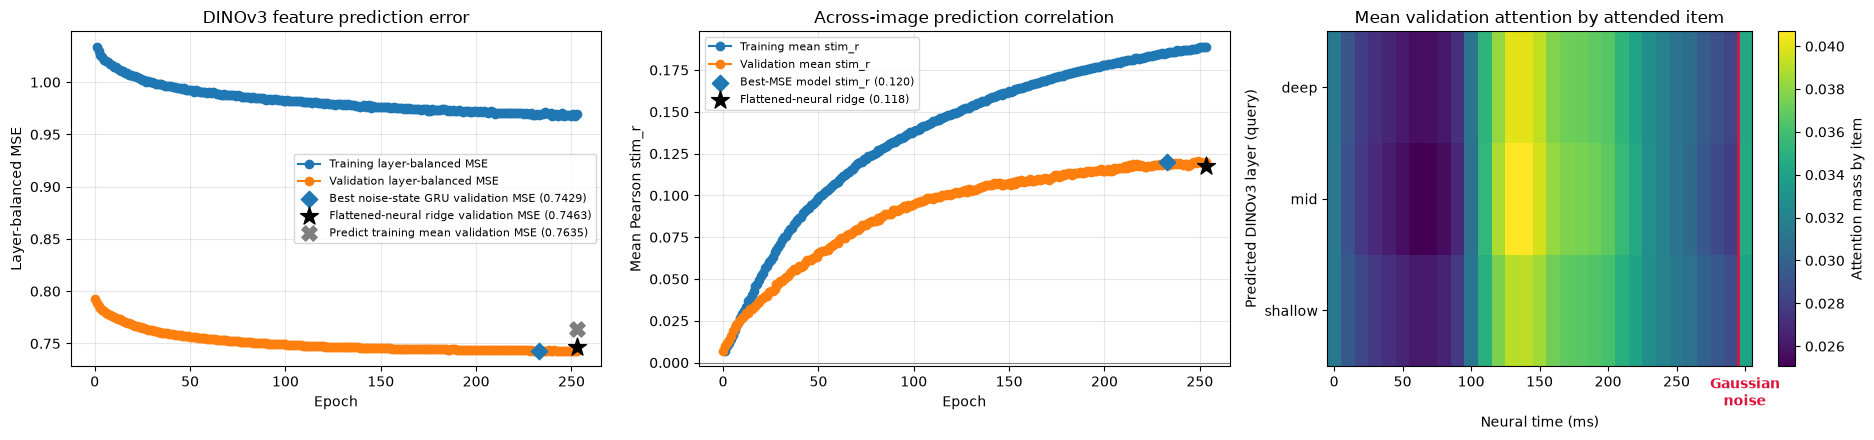

In [7]:
# Average attention over validation stimuli and independent noise draws.
torch.manual_seed(cfg.random_seed + 1)
n_repeats = cfg.noise_evaluation_repeats if cfg.noise_in_eval else 1
best_model_outputs = collect_feature_decoder_outputs(
    noise_model, validation_loader, device=device, n_repeats=n_repeats
)
attention_by_image, _ = average_rows_by_image(
    best_model_outputs[2], validation_trial_image_indices
)
mean_item_attention = attention_by_image.mean(axis=0)  # [layers, T + 1]

n_time_bins = raster_array.shape[1]
time_ms = cfg.time_start_ms + np.arange(n_time_bins) * 1000.0 / cfg.new_fs
if mean_item_attention.shape[1] != n_time_bins + 1:
    raise RuntimeError('Attention items do not match time bins plus noise.')
# end if the attended item axis is inconsistent
noise_attention = mean_item_attention[:, -1]
uniform_attention = 1.0 / (n_time_bins + 1)
print(
    'mean noise attention by DINOv3 layer: '
    + ', '.join(
        f'{layer_label} {value:.4f}'
        for layer_label, value in zip(cfg.layer_labels, noise_attention)
    )
)
print(f'overall mean noise attention: {noise_attention.mean():.4f} (uniform {uniform_attention:.4f})')

history = histories['GRU + noise state']
training_epochs = np.arange(1, len(history['training_losses']) + 1)
validation_epochs = np.arange(0, len(history['validation_losses']))
all_validation_losses = np.asarray(history['validation_losses'])
best_validation_epoch = history['best_epoch']
best_validation_loss = history['best_validation_loss']
all_validation_correlations = np.asarray(history['validation_correlations'])
best_model_validation_correlation = all_validation_correlations[best_validation_epoch]
print(
    f'noise-state GRU | best validation {best_validation_loss:.6f} '
    f'at epoch {best_validation_epoch:03d}'
)

# Plot optimization error and the final validation-set attention schedule.
fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))
axes[0].plot(
    training_epochs,
    history['training_losses'],
    marker='o',
    label='Training layer-balanced MSE',
)
axes[0].plot(
    validation_epochs,
    all_validation_losses,
    marker='o',
    label='Validation layer-balanced MSE',
)
axes[0].scatter(
    best_validation_epoch,
    best_validation_loss,
    marker='D',
    s=70,
    zorder=4,
    label=f'Best noise-state GRU validation MSE ({best_validation_loss:.4f})',
)
axes[0].scatter(
    validation_epochs[-1],
    ridge_validation_mse,
    marker='*',
    s=180,
    color='black',
    zorder=4,
    label=f'Flattened-neural ridge validation MSE ({ridge_validation_mse:.4f})',
)
axes[0].scatter(
    validation_epochs[-1],
    mean_validation_mse,
    marker='X',
    s=120,
    color='tab:gray',
    zorder=4,
    label=f'Predict training mean validation MSE ({mean_validation_mse:.4f})',
)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Layer-balanced MSE')
axes[0].set_title('DINOv3 feature prediction error')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

# Correlation is computed across validation images for every PCA coordinate,
# then averaged over the finite coordinates. It is insensitive to output scale.
axes[1].plot(
    training_epochs,
    history['training_correlations'][1:],
    marker='o',
    label='Training mean stim_r',
)
axes[1].plot(
    validation_epochs,
    all_validation_correlations,
    marker='o',
    label='Validation mean stim_r',
)
axes[1].scatter(
    best_validation_epoch,
    best_model_validation_correlation,
    marker='D',
    s=70,
    zorder=4,
    label=f'Best-MSE model stim_r ({best_model_validation_correlation:.3f})',
)
axes[1].scatter(
    validation_epochs[-1],
    ridge_validation_correlation,
    marker='*',
    s=180,
    color='black',
    zorder=4,
    label=f'Flattened-neural ridge ({ridge_validation_correlation:.3f})',
)
axes[1].axhline(0.0, color='grey', linewidth=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Pearson stim_r')
axes[1].set_title('Across-image prediction correlation')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

# Neural time on the horizontal axis, with the noise item as the last column.
attention_image = axes[2].imshow(
    mean_item_attention,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    cmap='viridis',
)
axes[2].set_yticks(np.arange(len(cfg.layer_labels)))
axes[2].set_yticklabels(cfg.layer_labels)
axes[2].set_ylabel('Predicted DINOv3 layer (query)')
axes[2].set_xlabel('Neural time (ms)')
axes[2].set_title('Mean validation attention by attended item')
item_tick_indices = [*range(0, n_time_bins, 5), n_time_bins]
axes[2].set_xticks(item_tick_indices)
# Two lines keep the noise label from colliding with the last time tick.
axes[2].set_xticklabels([*time_ms[::5].astype(int), 'Gaussian\nnoise'])
noise_tick = axes[2].get_xticklabels()[-1]
noise_tick.set_color('crimson')
noise_tick.set_fontweight('bold')

# Separate the stimulus-independent noise column from the real time bins.
axes[2].axvline(n_time_bins - 0.5, color='crimson', linewidth=2)
fig.colorbar(
    attention_image,
    ax=axes[2],
    label='Attention mass by item',
)
fig.tight_layout()
plt.show()

## Dynamic RSA of observed neural time against predicted layers

This is the closest counterpart of the neural notebook's dRSA figure. There, both axes are time because the model predicts a neural time course. Here the model predicts static features, so the rows stay real neural time and the columns become the three predicted DINOv3 layers.

For every neural time bin, an RDM is computed across validation images from the observed population response. Separate RDMs are computed for each predicted layer, from the restored best model and from ridge. Each matrix entry compares one observed-neural RDM (row) with one predicted-layer RDM (column). A 30 x 3 matrix has no diagonal, so the third panel shows one RSA time course per predicted layer: it says at which neural latency the decoded geometry of each layer most resembles the observed population geometry.

Best noise-state GRU   | shallow  | peak RSA 0.465 at 170 ms | mean 0.159
Best noise-state GRU   | mid      | peak RSA 0.474 at 170 ms | mean 0.164
Best noise-state GRU   | deep     | peak RSA 0.475 at 170 ms | mean 0.160
Flattened-neural ridge | shallow  | peak RSA 0.553 at 170 ms | mean 0.235
Flattened-neural ridge | mid      | peak RSA 0.560 at 170 ms | mean 0.233
Flattened-neural ridge | deep     | peak RSA 0.562 at 170 ms | mean 0.227


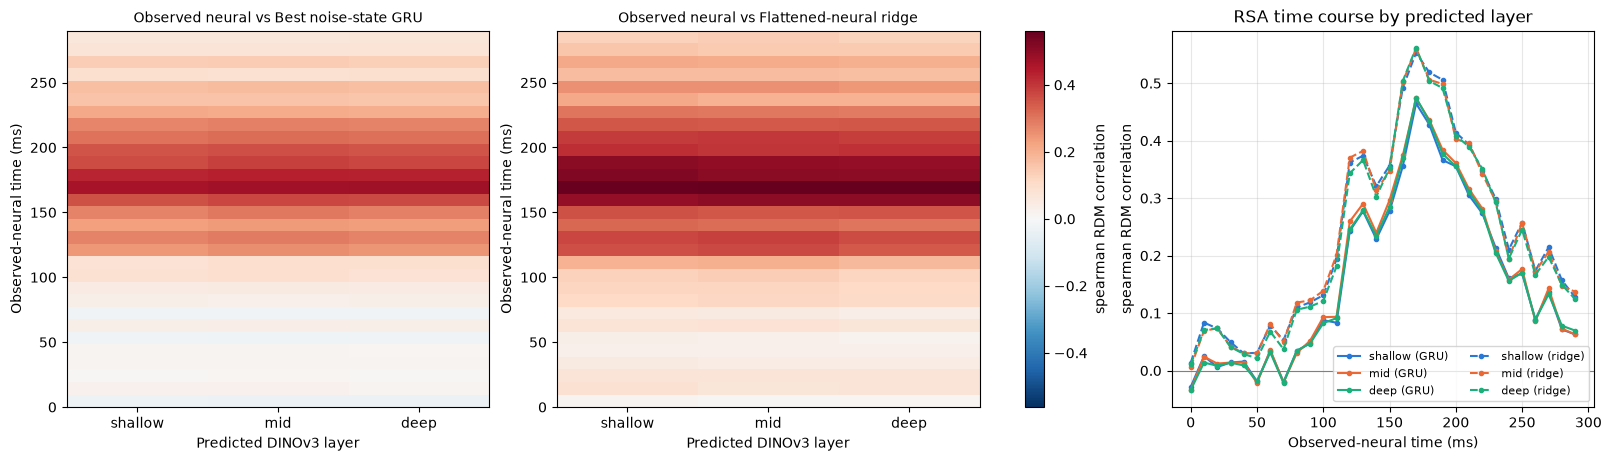

In [8]:
if len(set(target_dims)) != 1:
    raise ValueError('Layer-wise RSA needs the same PCA width for every layer.')
# end if layers cannot be stacked on one axis
best_model_predictions, best_model_image_ids = average_rows_by_image(
    best_model_outputs[0], validation_trial_image_indices
)
if not np.array_equal(best_model_image_ids, target_image_ids):
    raise RuntimeError(
        'Best-model and ridge targets are not aligned in validation-image order.'
    )
# end if image rows differ between prediction families

def as_layer_series(image_values):
    # Put layers on the axis that holds time in the neural notebook: [images, layers, D].
    return image_values.reshape(len(image_values), len(target_slices), target_dims[0])
# EOF

prepared_target_rdms = prepared_rdm_time_series(
    as_layer_series(validation_image_targets),
    rdm_metric=cfg.drsa_rdm_metric,
    rsa_metric=cfg.drsa_rsa_metric,
)
prepared_best_model_rdms = prepared_rdm_time_series(
    as_layer_series(best_model_predictions),
    rdm_metric=cfg.drsa_rdm_metric,
    rsa_metric=cfg.drsa_rsa_metric,
)
prepared_ridge_rdms = prepared_rdm_time_series(
    as_layer_series(ridge_image_predictions),
    rdm_metric=cfg.drsa_rdm_metric,
    rsa_metric=cfg.drsa_rsa_metric,
)

# The observed side is the decoder's own input: standardized AIT activity,
# averaged over repeated presentations of each validation image.
validation_neural_series, neural_image_ids = average_rows_by_image(
    full_dataset.neural_sequences.numpy()[validation_trial_indices],
    validation_trial_image_indices,
)
if not np.array_equal(neural_image_ids, target_image_ids):
    raise RuntimeError('Neural and target rows use different validation images.')
# end if the observed neural rows are misaligned
prepared_neural_rdms = prepared_rdm_time_series(
    validation_neural_series,
    rdm_metric=cfg.drsa_rdm_metric,
    rsa_metric=cfg.drsa_rsa_metric,
)
drsa_times_ms = time_axis_ms(
    validation_neural_series.shape[1],
    cfg.new_fs,
    cfg.time_start_ms,
)
layer_positions = np.arange(len(cfg.layer_labels))
layer_colors = ['#2a78d6', '#eb6834', '#1baf7a']

neural_time_drsa = {
    'Best noise-state GRU': drsa_from_prepared(
        prepared_neural_rdms,
        prepared_best_model_rdms,
    ),
    'Flattened-neural ridge': drsa_from_prepared(
        prepared_neural_rdms,
        prepared_ridge_rdms,
    ),
}
neural_time_limit = float(
    np.nanmax([
        np.abs(drsa_matrix)
        for drsa_matrix in neural_time_drsa.values()
    ])
)

fig, axes = plt.subplots(
    1, 3, figsize=(16, 4.5), layout='constrained'
)
for axis, (model_label, drsa_matrix) in zip(
    axes[:2], neural_time_drsa.items()
):
    # Same look as plot_drsa_matrix, without its identity line: the two axes
    # are neural time and layer depth, so a diagonal would be meaningless.
    drsa_image = axis.imshow(
        drsa_matrix,
        aspect='auto',
        origin='lower',
        interpolation='nearest',
        cmap='RdBu_r',
        vmin=-neural_time_limit,
        vmax=neural_time_limit,
        extent=(-0.5, len(cfg.layer_labels) - 0.5, drsa_times_ms[0], drsa_times_ms[-1]),
    )
    axis.set_xticks(layer_positions)
    axis.set_xticklabels(cfg.layer_labels)
    axis.set_title(f'Observed neural vs {model_label}', fontsize=10)
    axis.set_xlabel('Predicted DINOv3 layer')
    axis.set_ylabel('Observed-neural time (ms)')
# end for observed-neural dRSA matrix
fig.colorbar(
    drsa_image,
    ax=axes[:2],
    label=f'{cfg.drsa_rsa_metric} RDM correlation',
)

# One RSA time course per predicted layer; ridge is dashed for comparison.
for model_label, drsa_matrix in neural_time_drsa.items():
    is_ridge = model_label.startswith('Flattened')
    for layer_idx, layer_label in enumerate(cfg.layer_labels):
        rsa_time_course = drsa_matrix[:, layer_idx]
        peak_index = int(np.nanargmax(rsa_time_course))
        axes[2].plot(
            drsa_times_ms,
            rsa_time_course,
            marker='o',
            markersize=3,
            color=layer_colors[layer_idx],
            linestyle='--' if is_ridge else '-',
            label=f'{layer_label} ({"ridge" if is_ridge else "GRU"})',
        )
        print(
            f'{model_label:22s} | {layer_label:8s} | peak RSA '
            f'{rsa_time_course[peak_index]:.3f} at '
            f'{drsa_times_ms[peak_index]:.0f} ms | '
            f'mean {np.nanmean(rsa_time_course):.3f}'
        )
    # end for predicted layer
# end for prediction family
axes[2].axhline(0.0, color='grey', linewidth=0.8)
axes[2].set_xlabel('Observed-neural time (ms)')
axes[2].set_ylabel(f'{cfg.drsa_rsa_metric} RDM correlation')
axes[2].set_title('RSA time course by predicted layer')
axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=8, ncol=2)
plt.show()

## Layer-wise RSA of ridge and best-model predictions

The same comparison restricted to the feature side, where a matched-layer diagonal exists. One validation-image RDM is computed for every DINOv3 layer, from the target PCA coordinates, from the best noise-state GRU predictions, and from ridge. Each matrix entry compares one target-layer RDM (row) with one predicted-layer RDM (column); off-diagonal structure shows whether a decoded layer resembles the geometry of another depth.

Best noise-state GRU      | peak aligned RSA 0.212 at shallow | mean 0.162
Flattened-neural ridge    | peak aligned RSA 0.207 at shallow | mean 0.160


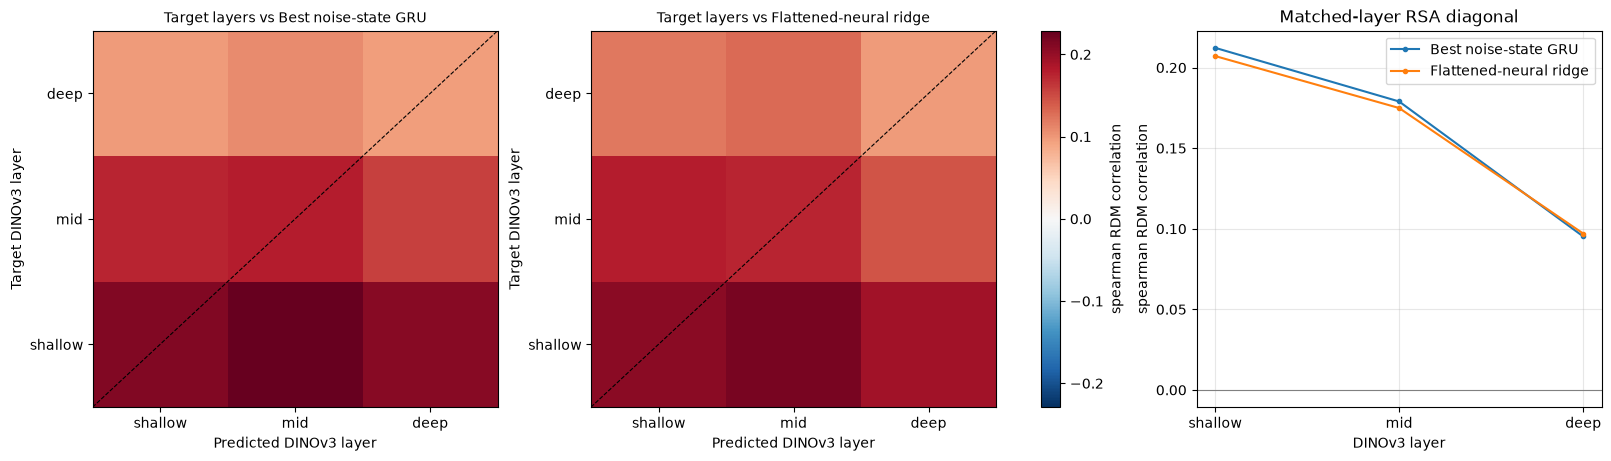

In [9]:
prediction_drsa = {
    'Best noise-state GRU': drsa_from_prepared(
        prepared_target_rdms,
        prepared_best_model_rdms,
    ),
    'Flattened-neural ridge': drsa_from_prepared(
        prepared_target_rdms,
        prepared_ridge_rdms,
    ),
}
# plot_drsa_matrix reads only the axis end points, so cell edges center each layer.
layer_edges = np.array([-0.5, len(cfg.layer_labels) - 0.5])
drsa_limit = float(
    np.nanmax([
        np.abs(drsa_matrix)
        for drsa_matrix in prediction_drsa.values()
    ])
)

fig, axes = plt.subplots(
    1, 3, figsize=(16, 4.5), layout='constrained'
)
for axis, (model_label, drsa_matrix) in zip(
    axes[:2], prediction_drsa.items()
):
    drsa_image = plot_drsa_matrix(
        axis,
        drsa_matrix,
        layer_edges,
        layer_edges,
        f'Target layers vs {model_label}',
        row_label='Target DINOv3 layer',
        column_label='Predicted DINOv3 layer',
        vmin=-drsa_limit,
        vmax=drsa_limit,
    )
    axis.set_xticks(layer_positions)
    axis.set_xticklabels(cfg.layer_labels)
    axis.set_yticks(layer_positions)
    axis.set_yticklabels(cfg.layer_labels)
# end for predicted-layer RSA matrix
fig.colorbar(
    drsa_image,
    ax=axes[:2],
    label=f'{cfg.drsa_rsa_metric} RDM correlation',
)

# The identity diagonal compares target and predicted geometry at equal depth.
for model_label, drsa_matrix in prediction_drsa.items():
    aligned_drsa = np.diagonal(drsa_matrix)
    peak_index = int(np.nanargmax(aligned_drsa))
    axes[2].plot(
        layer_positions,
        aligned_drsa,
        marker='o',
        markersize=3,
        label=model_label,
    )
    print(
        f'{model_label:25s} | peak aligned RSA '
        f'{aligned_drsa[peak_index]:.3f} at {cfg.layer_labels[peak_index]} | '
        f'mean {np.nanmean(aligned_drsa):.3f}'
    )
# end for aligned RSA profile
axes[2].axhline(0.0, color='grey', linewidth=0.8)
axes[2].set_xticks(layer_positions)
axes[2].set_xticklabels(cfg.layer_labels)
axes[2].set_xlabel('DINOv3 layer')
axes[2].set_ylabel(f'{cfg.drsa_rsa_metric} RDM correlation')
axes[2].set_title('Matched-layer RSA diagonal')
axes[2].grid(alpha=0.3)
axes[2].legend()
plt.show()